In [1]:
import torch
from tqdm import tqdm
from sbi.inference import SNLE
import matplotlib.pyplot as plt

from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import PatchForagingDDM, create_prior
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.snle.snle_inference import train_snle, infer_parameters_snle
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.snle.snle_utils import plot_training_history

SNLE TRAINING FOR PATCH-LEVEL INFERENCE
Generating 100000 training samples (mode=multi)...


  0%|          | 30/100000 [00:00<05:49, 286.34it/s]


First sample check:
  theta: tensor([1.1389, 0.4262, 0.6046])
  summary_stats: tensor([ 1.2960,  0.3637,  1.3158,  0.5218,  0.2500,  0.4933, 19.0000, 76.0000])
  has NaN: False


100%|██████████| 100000/100000 [03:02<00:00, 548.03it/s]



Number of samples with NaN: 0/100000
Training data shape: theta=torch.Size([100000, 3]), x=torch.Size([100000, 8])
Multi-patch aggregate stats (8 features): mean_time, std_time, mean_stops, std_stops, mean_rewards, std_rewards, total_rewards, num_patches

Training SNLE (multi mode)...
 Training neural network. Epochs trained: 51
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 51
        Best validation performance: -22.0954
        -------------------------
        

SNLE training complete (multi mode)!
Epochs trained: 51
Final train loss: -21.5227
Final validation loss: -22.0954
Best validation loss: -22.0954


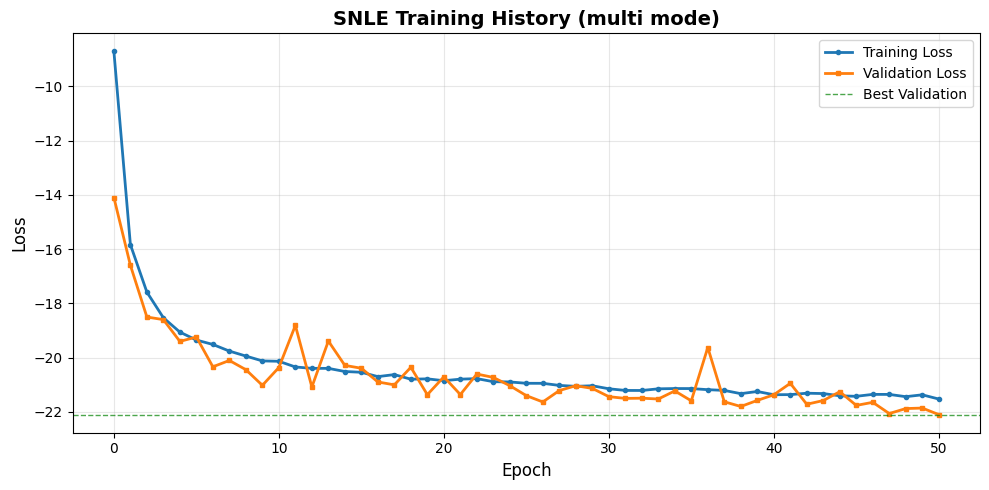


Training Diagnostics:
Epochs trained:        51
Final training loss:   -21.5227
Final validation loss: -22.0954
Best validation loss:  -22.0954
Train-val gap:         -0.5728

⚠️  WARNING: Validation loss much lower than training loss (unusual)
   This might indicate issues with validation split


In [2]:
torch.manual_seed(1)
    
# Setup
simulator = PatchForagingDDM()
prior = create_prior()

print("="*60)
print("SNLE TRAINING FOR PATCH-LEVEL INFERENCE")
print("="*60)

# Train multi-patch model
likelihood_estimator_multi, inference_multi, x_mean_multi, x_std_multi, history_multi = train_snle(
    simulator, prior, num_simulations=100000, window_sites=100, mode='multi'
)

# Plot training history
plot_training_history(history_multi, mode='multi')

In [3]:
print("\n" + "="*60)
print("TESTING INFERENCE")
print("="*60)

# Test on a simulated patch
true_theta = torch.tensor([0.4, 0.2, 0.3])
print(f"\nTrue parameters: {true_theta}")

# Simulate observed patch
global_time = 0.0
patch_start_time = 0.0

# Test multi-patch inference
param_gen = simulator.constant_params(true_theta)
_, observed_stats_multi = simulator.simulate_trial(param_gen, 100, return_aggregate=True)

print(f"Observed summary stats: {observed_stats_multi}")
print(f"  - Total time: {observed_stats_multi[0]:.2f}")
print(f"  - Num stops: {observed_stats_multi[1]:.0f}")
print(f"  - Num rewards: {observed_stats_multi[2]:.0f}")

# Infer parameters - pass inference object, not likelihood_estimator
posterior_samples_multi = infer_parameters_snle(
    inference_multi, 
    observed_stats_multi, 
    x_mean_multi, 
    x_std_multi,
    num_samples=1000, 
    warmup_steps=200
)

# Analyze results
posterior_mean = posterior_samples_multi.mean(dim=0)
posterior_std = posterior_samples_multi.std(dim=0)

print(f"\nInference results:")
print(f"True parameters:      {true_theta}")
print(f"Posterior mean:       {posterior_mean}")
print(f"Posterior std:        {posterior_std}")
print(f"Absolute error:       {(posterior_mean - true_theta).abs()}")


TESTING INFERENCE

True parameters: tensor([0.4000, 0.2000, 0.3000])
Observed summary stats: tensor([ 3.6179,  0.9628,  3.6429,  0.8698,  2.0357,  1.1701, 57.0000, 28.0000])
  - Total time: 3.62
  - Num stops: 1
  - Num rewards: 4
Running MCMC to infer parameters...


/opt/miniconda3/envs/sbi_ddm_py311/lib/python3.11/site-packages/sbi/inference/trainers/base.py:577: FutureWarning: The following arguments are deprecated and will be removed in a future version: mcmc_parameters. Please use `posterior_parameters` instead. Refer to this guide for details:
https://sbi.readthedocs.io/en/latest/how_to_guide/19_posterior_parameters.html#
  self._raise_deprecation_warning(deprecated_params, **kwargs)


Generating 1 MCMC inits via resample strategy:   0%|          | 0/1 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/6050 [00:00<?, ?it/s]


Inference results:
True parameters:      tensor([0.4000, 0.2000, 0.3000])
Posterior mean:       tensor([0.3227, 0.0938, 0.9689])
Posterior std:        tensor([0.0614, 0.0821, 0.3083])
Absolute error:       tensor([0.0773, 0.1062, 0.6689])


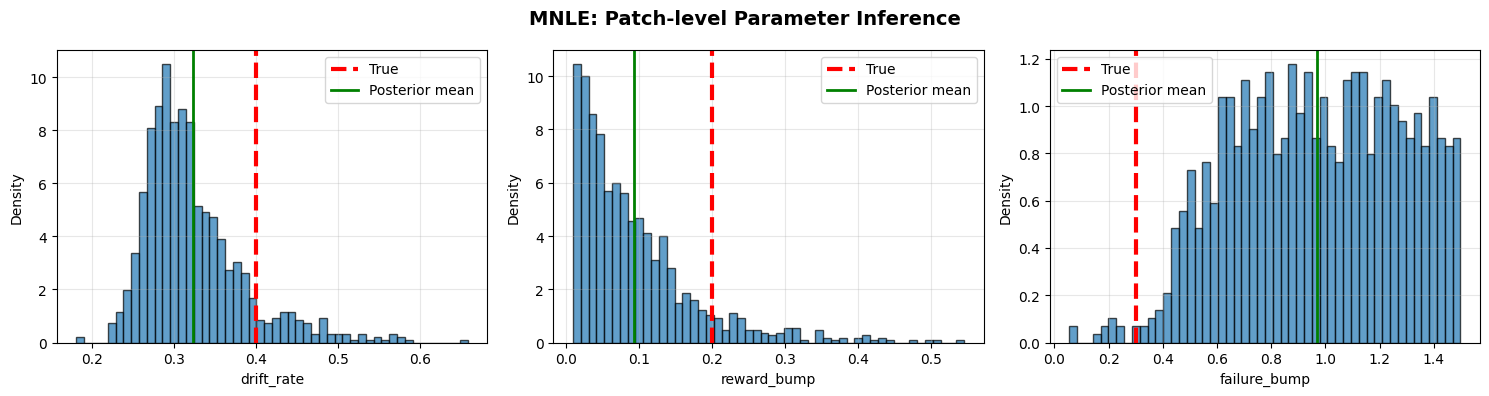

In [4]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
param_names = ['drift_rate', 'reward_bump', 'failure_bump']

for i, (ax, name) in enumerate(zip(axes, param_names)):
    ax.hist(posterior_samples_multi[:, i].numpy(), bins=50, 
            density=True, alpha=0.7, edgecolor='black')
    ax.axvline(true_theta[i].item(), color='red', 
                linestyle='--', linewidth=3, label='True')
    ax.axvline(posterior_mean[i].item(), color='green', 
                linestyle='-', linewidth=2, label='Posterior mean')
    ax.set_xlabel(name)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('MNLE: Patch-level Parameter Inference', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_99203/1973464683.py:7: DeprecationWarning: you passed deprecated arguments **kwargs: ['kde_offdiag', 'kde_diag', 'contour_offdiag', 'points_colors', 'points_offdiag'], use fig_kwargs instead. We continue calling the deprecated pairplot function
  fig, ax = pairplot(


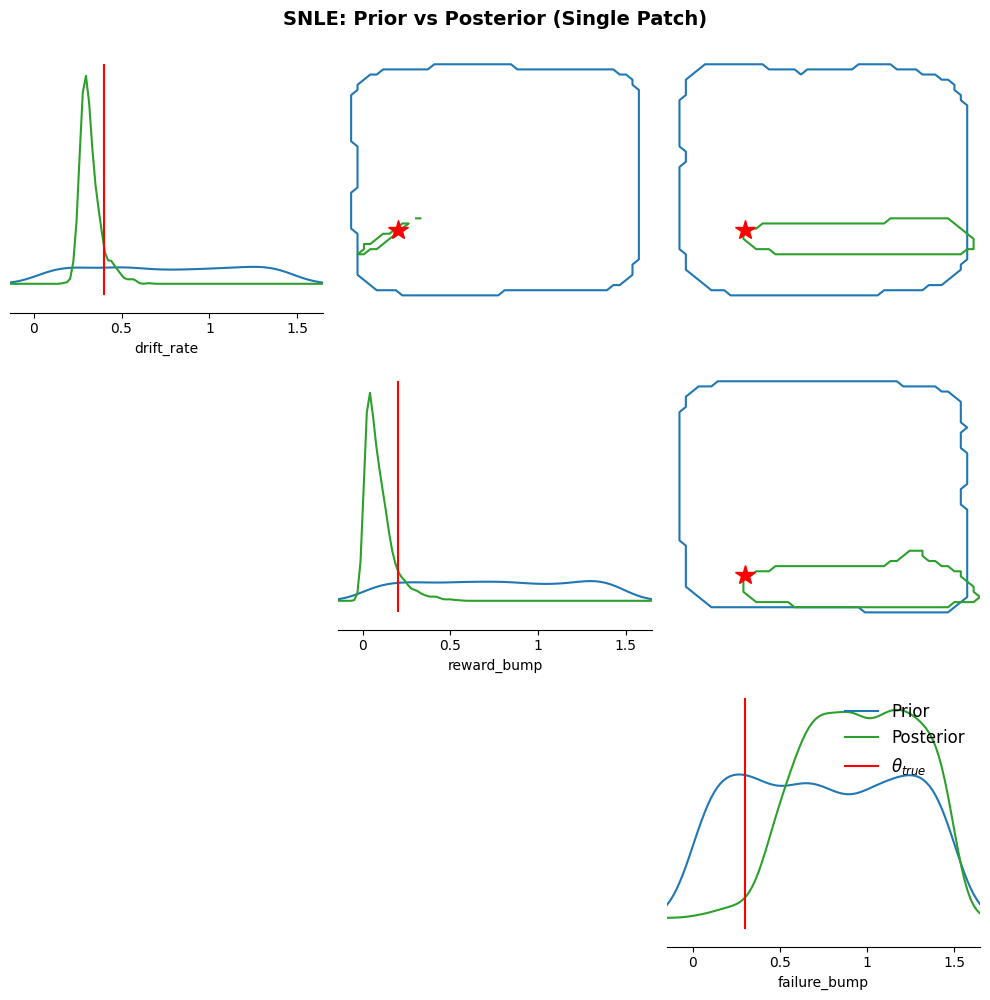

In [5]:
from sbi.analysis import pairplot

# Generate prior samples for comparison
prior_samples = prior.sample((1000,))

# Create pairplot comparing prior and posterior
fig, ax = pairplot(
    [prior_samples, posterior_samples_multi],
    points=true_theta,  # True parameters as a point
    diag="kde",
    upper="contour", 
    kde_offdiag=dict(bins=50),
    kde_diag=dict(bins=100),
    contour_offdiag=dict(levels=[0.95]),
    points_colors=["red"], 
    points_offdiag=dict(marker="*", markersize=15), 
    labels=[r"drift_rate", r"reward_bump", r"failure_bump"],
    figsize=(10, 10)
)

# Add legend
plt.sca(ax[2, 2])  # Select the bottom-right subplot
plt.legend(
    ["Prior", "Posterior", r"$\theta_{true}$"], 
    frameon=False, 
    fontsize=12,
    loc='upper right'
)

plt.suptitle('SNLE: Prior vs Posterior (Single Patch)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


Generating patches from posterior samples for comparison...
Real data shape: torch.Size([100, 3])
Synthetic data shape: torch.Size([100, 3])


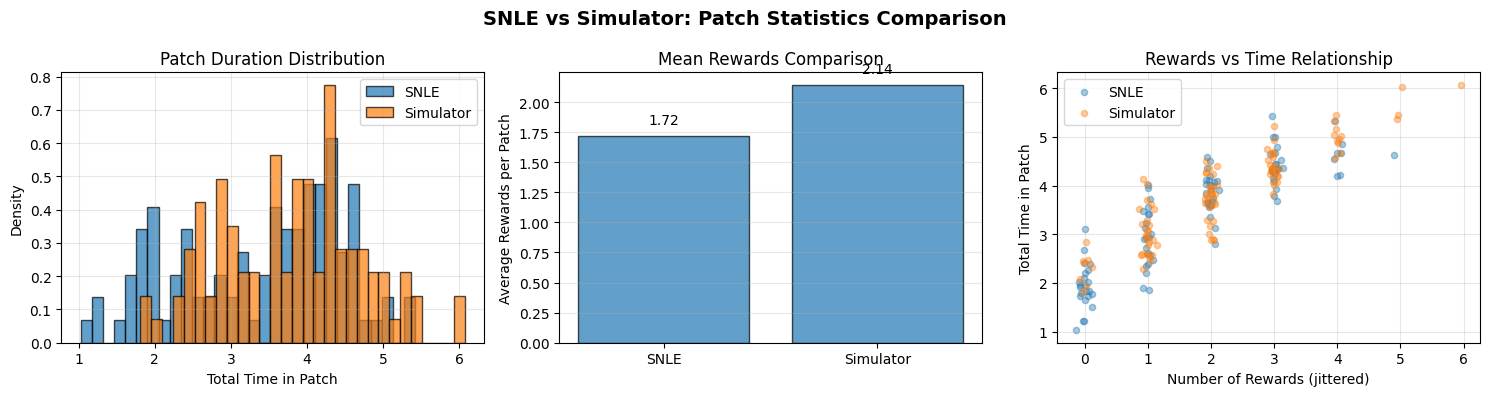


COMPARISON SUMMARY

Total Time in Patch:
  SNLE:      3.400 ± 1.083
  Simulator: 3.792 ± 0.940

Number of Stops:
  SNLE:      3.410 ± 1.026
  Simulator: 3.780 ± 1.079

Number of Rewards:
  SNLE:      1.720 ± 1.296
  Simulator: 2.140 ± 1.279


In [6]:
import numpy as np

# Generate multiple patches from posterior samples to compare distributions
print("\nGenerating patches from posterior samples for comparison...")

num_comparison_patches = 100

# 1. Generate "real" data from true simulator with true parameters
real_patches = []
for _ in range(num_comparison_patches):
    global_time = 0.0
    patch_start_time = 0.0
    _, _, stats = simulator._simulate_one_patch(true_theta, global_time, patch_start_time)
    real_patches.append(stats)
real_data = torch.stack(real_patches)

# 2. Generate "synthetic" data from simulator using posterior-sampled parameters
synthetic_patches = []
for i in range(num_comparison_patches):
    # Sample a parameter from posterior
    theta_sample = posterior_samples_multi[i % len(posterior_samples_multi)]
    
    global_time = 0.0
    patch_start_time = 0.0
    _, _, stats = simulator._simulate_one_patch(theta_sample, global_time, patch_start_time)
    synthetic_patches.append(stats)
synthetic_data = torch.stack(synthetic_patches)

print(f"Real data shape: {real_data.shape}")
print(f"Synthetic data shape: {synthetic_data.shape}")

# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Time in patch distributions
axes[0].hist(synthetic_data[:, 0].numpy(), bins=30, alpha=0.7, label='SNLE', 
             density=True, edgecolor='black')
axes[0].hist(real_data[:, 0].numpy(), bins=30, alpha=0.7, label='Simulator', 
             density=True, edgecolor='black')
axes[0].set_xlabel('Total Time in Patch')
axes[0].set_ylabel('Density')
axes[0].set_title('Patch Duration Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Average rewards comparison
synth_rewards = synthetic_data[:, 2].mean()  # Column 2 is num_rewards
real_rewards = real_data[:, 2].mean()

axes[1].bar(['SNLE', 'Simulator'], [synth_rewards, real_rewards], 
            alpha=0.7, edgecolor='black', capsize=5)
axes[1].set_ylabel('Average Rewards per Patch')
axes[1].set_title('Mean Rewards Comparison')
axes[1].grid(True, alpha=0.3, axis='y')

# Add text labels on bars
for i, (label, value) in enumerate(zip(['SNLE', 'Simulator'], [synth_rewards, real_rewards])):
    axes[1].text(i, value + 0.1, f'{value:.2f}', ha='center', fontsize=10)

# Plot 3: Rewards vs Time scatter
axes[2].scatter(synthetic_data[:, 2].numpy() + np.random.normal(0, 0.05, num_comparison_patches), 
                synthetic_data[:, 0].numpy(), alpha=0.4, label='SNLE', s=20)
axes[2].scatter(real_data[:, 2].numpy() + np.random.normal(0, 0.05, num_comparison_patches), 
                real_data[:, 0].numpy(), alpha=0.4, label='Simulator', s=20)
axes[2].set_xlabel('Number of Rewards (jittered)')
axes[2].set_ylabel('Total Time in Patch')
axes[2].set_title('Rewards vs Time Relationship')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('SNLE vs Simulator: Patch Statistics Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(f"\nTotal Time in Patch:")
print(f"  SNLE:      {synthetic_data[:, 0].mean():.3f} ± {synthetic_data[:, 0].std():.3f}")
print(f"  Simulator: {real_data[:, 0].mean():.3f} ± {real_data[:, 0].std():.3f}")
print(f"\nNumber of Stops:")
print(f"  SNLE:      {synthetic_data[:, 1].mean():.3f} ± {synthetic_data[:, 1].std():.3f}")
print(f"  Simulator: {real_data[:, 1].mean():.3f} ± {real_data[:, 1].std():.3f}")
print(f"\nNumber of Rewards:")
print(f"  SNLE:      {synthetic_data[:, 2].mean():.3f} ± {synthetic_data[:, 2].std():.3f}")
print(f"  Simulator: {real_data[:, 2].mean():.3f} ± {real_data[:, 2].std():.3f}")
print("="*60)